In [13]:
import pandas as pd

In [14]:
sm1 = pd.read_csv('./data/sample1.csv', index_col=0)
print(sm1.shape)
sm1.head(2)

(500000, 21)


,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,AVG_DEPTH,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND
0,0,30,32.0,0,0,0,6,2,0,2,...,24.285714,1,1,21490.0,0,0,0,0,4,0
1,0,41,0.0,0,0,0,15,4,0,4,...,16.666667,0,1,26085.0,0,1,0,0,6,1


In [15]:
sm2 = pd.read_csv('./data/sample2.csv', index_col=0)
print(sm2.shape)
sm2.head(2)

(548036, 21)


,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,AVG_DEPTH,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND
500000,0,43,0.0,0,0,0,4,1,0,2,...,41.111111,0,1,290.322812,0,1,0,0,4,0
500001,0,43,0.0,0,0,0,4,1,0,2,...,50.909091,0,1,290.322812,0,1,0,0,5,1


In [16]:
df = pd.concat([sm1, sm2])
print(df.shape)
df.head(2)

(1048036, 21)


,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,AVG_DEPTH,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND
0,0,30,32.0,0,0,0,6,2,0,2,...,24.285714,1,1,21490.0,0,0,0,0,4,0
1,0,41,0.0,0,0,0,15,4,0,4,...,16.666667,0,1,26085.0,0,1,0,0,6,1


In [17]:
def determine_age(row):
    if row['AGE_30'] == 1:
        return 30
    elif row['AGE_50'] == 1:
        return 50
    elif row['AGE_60'] == 1:
        return 60
    elif row['AGE_1020'] == 1:
        return 20
    else:
        return 40  # 모든 값이 0이면 40

df['AGE'] = df.apply(determine_age, axis=1)
df.head(2)

,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND,AGE
0,0,30,32.0,0,0,0,6,2,0,2,...,1,1,21490.0,0,0,0,0,4,0,40
1,0,41,0.0,0,0,0,15,4,0,4,...,0,1,26085.0,0,1,0,0,6,1,50


In [18]:
y1 = df[df['y'] == 1]

# y가 1인 행 중 절반 샘플링 (무작위, random_state로 재현성 설정 가능)

# y가 0인 행 추출
y0 = df[df['y'] == 0]

y0_sampled = y0.sample(frac=0.9, random_state=42)


# y0 전체와 y1_sampled 합치기
df_new = pd.concat([y0_sampled, y1]).sort_index().reset_index(drop=True)

print(df_new.shape)


(946423, 22)


In [19]:
df_origin = df_new[['y', 'msg_length', 'max_discount', 'personalized', 'time_pressure', 'AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT',
       'AVG_DEPTH', 'day_off', 'WEEKEND']]

### 각 변수 EDA

변수명: y
데이터 유형: int64
기초 통계량:
count    946423.000000
mean          0.033709
std           0.180479
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: y, dtype: float64
빈도 분포:
y
0    914520
1     31903
Name: count, dtype: int64


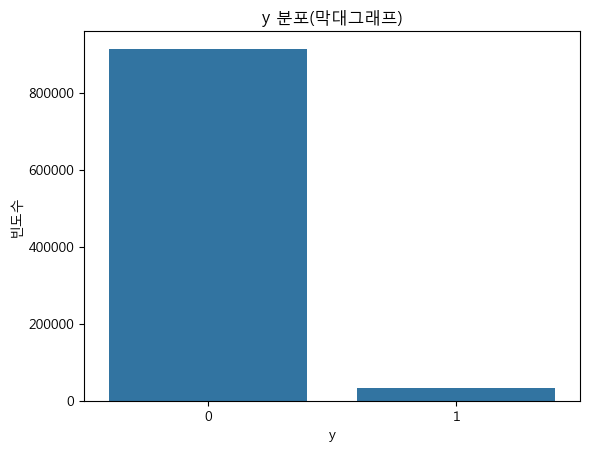

변수명: msg_length
데이터 유형: int64
기초 통계량:
count    946423.000000
mean        100.757921
std          94.740722
min          17.000000
25%          30.000000
50%          45.000000
75%         177.000000
max         329.000000
Name: msg_length, dtype: float64


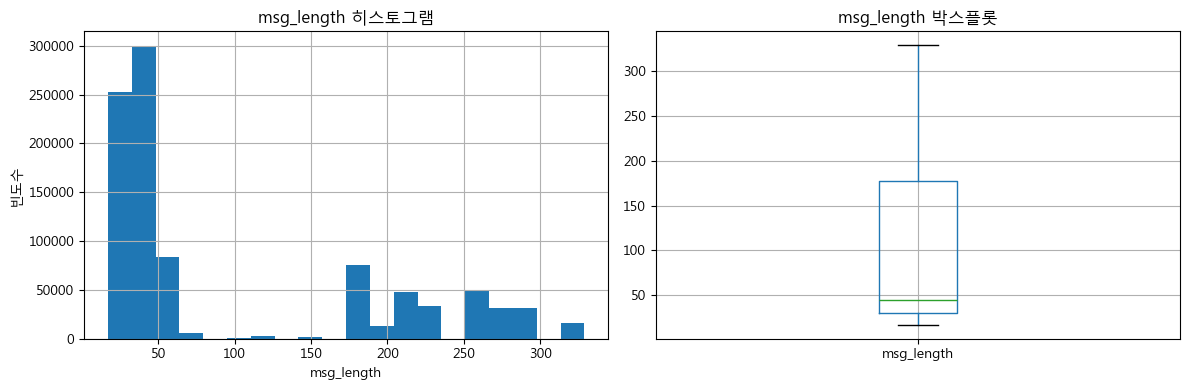

변수명: max_discount
데이터 유형: float64
기초 통계량:
count    946423.000000
mean         33.160648
std          21.056968
min           0.000000
25%          28.000000
50%          33.333333
75%          50.000000
max         100.000000
Name: max_discount, dtype: float64


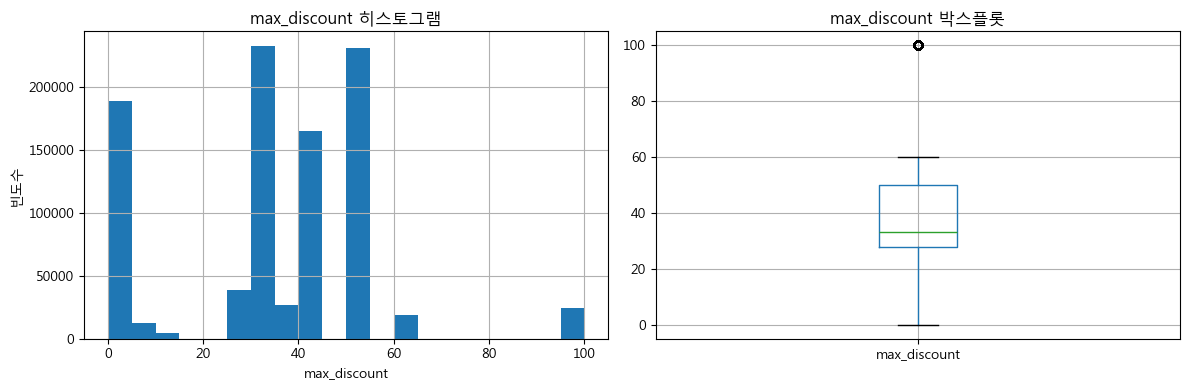

변수명: personalized
데이터 유형: int64
기초 통계량:
count    946423.000000
mean          0.174378
std           0.379434
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: personalized, dtype: float64
빈도 분포:
personalized
0    781388
1    165035
Name: count, dtype: int64


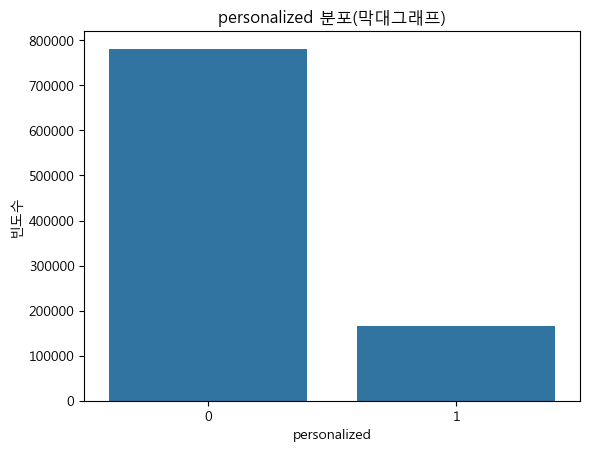

변수명: time_pressure
데이터 유형: int64
기초 통계량:
count    946423.000000
mean          0.032912
std           0.178407
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: time_pressure, dtype: float64
빈도 분포:
time_pressure
0    915274
1     31149
Name: count, dtype: int64


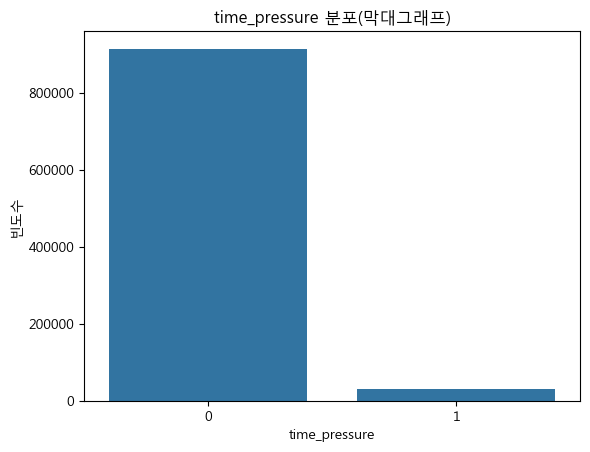

변수명: AVG_SAL_AMT
데이터 유형: float64
기초 통계량:
count    946423.000000
mean      14686.784426
std        9175.152038
min           0.000000
25%        8403.532544
50%       14212.500000
75%       19554.166667
max      263500.000000
Name: AVG_SAL_AMT, dtype: float64


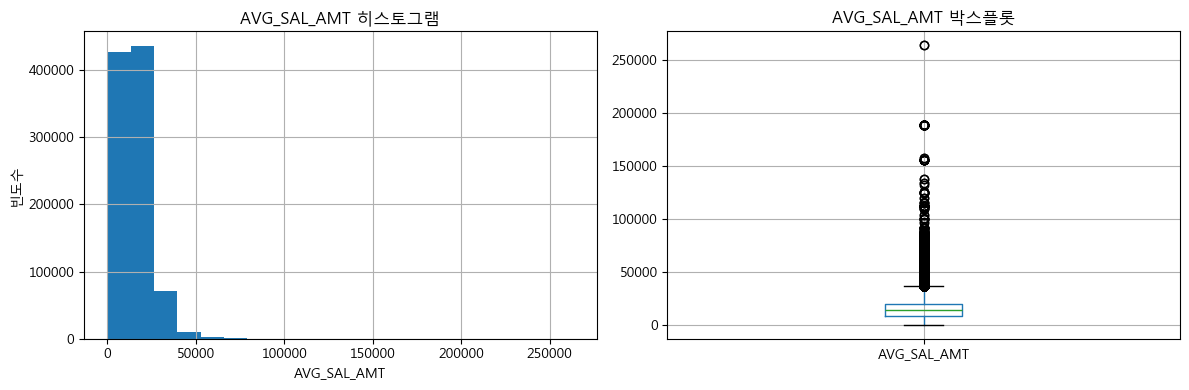

변수명: SRCH_EFRT
데이터 유형: int64
기초 통계량:
count    946423.000000
mean         16.555230
std          20.464566
min           4.000000
25%           5.000000
50%           9.000000
75%          19.000000
max         484.000000
Name: SRCH_EFRT, dtype: float64


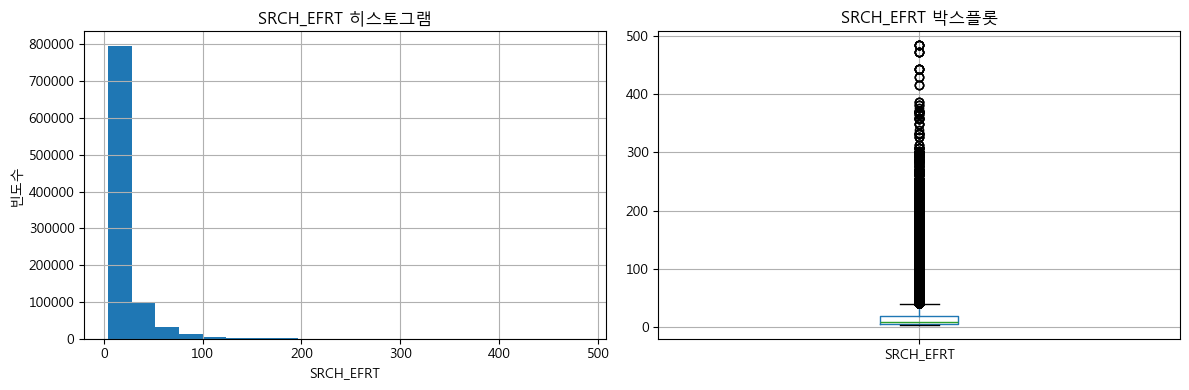

변수명: CAT_CNT
데이터 유형: int64
기초 통계량:
count    946423.000000
mean          0.548828
std           0.832782
min          -1.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           8.000000
Name: CAT_CNT, dtype: float64


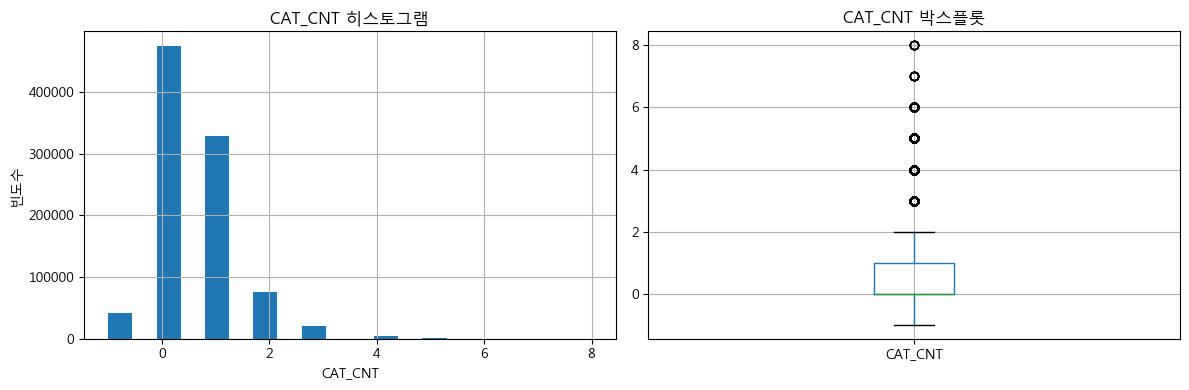

변수명: AVG_DEPTH
데이터 유형: float64
기초 통계량:
count    946423.000000
mean         26.160913
std          15.746459
min          10.000000
25%          10.000000
50%          21.666667
75%          42.000000
max         100.000000
Name: AVG_DEPTH, dtype: float64


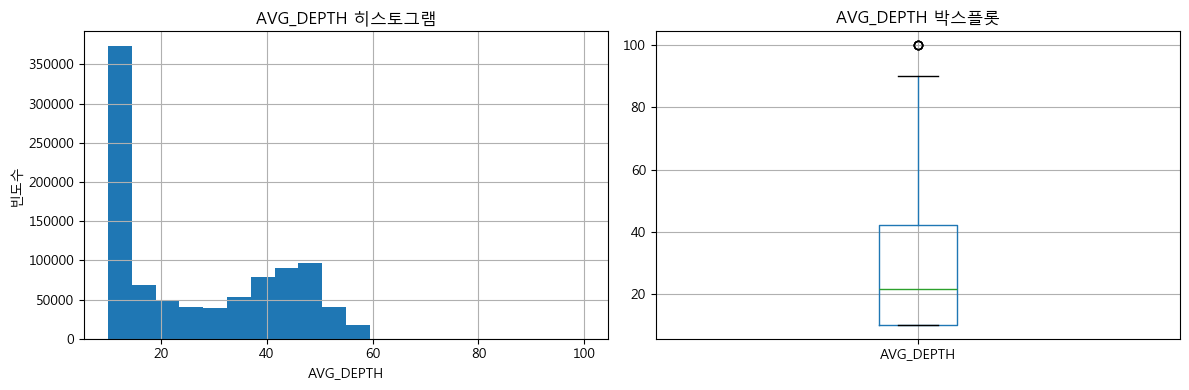

변수명: day_off
데이터 유형: int64
기초 통계량:
count    946423.000000
mean          0.567796
std           0.495383
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: day_off, dtype: float64
빈도 분포:
day_off
1    537375
0    409048
Name: count, dtype: int64


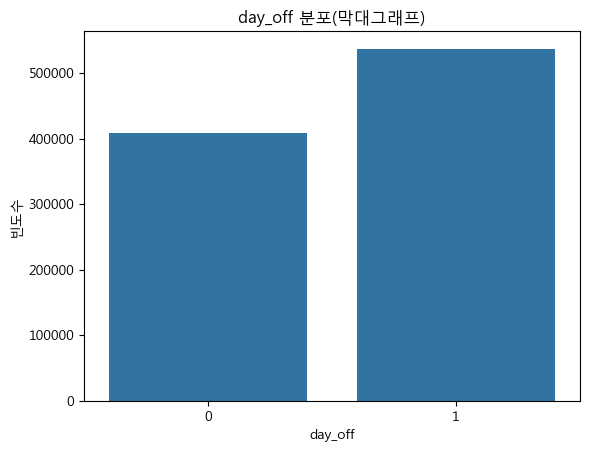

변수명: WEEKEND
데이터 유형: int64
기초 통계량:
count    946423.000000
mean          0.264688
std           0.441167
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: WEEKEND, dtype: float64
빈도 분포:
WEEKEND
0    695916
1    250507
Name: count, dtype: int64


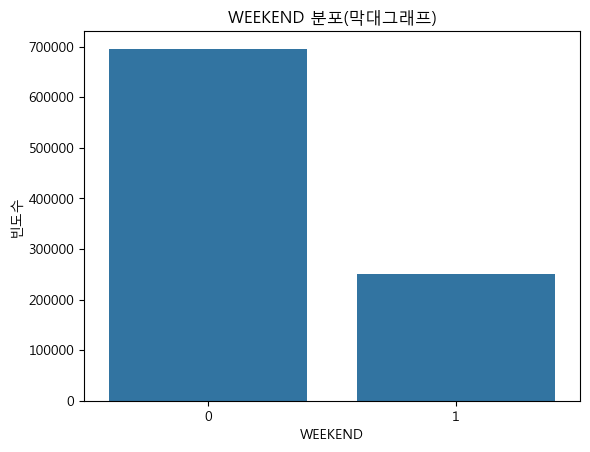

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family="Malgun Gothic")

import warnings 
warnings.filterwarnings("ignore")


for col in df_origin.columns:
    print('='*50)
    print(f"변수명: {col}")
    print("데이터 유형:", df_origin[col].dtype)

    # 변수에 대한 기초 통계량 출력
    print("기초 통계량:")
    print(df_origin[col].describe())

    if df_origin[col].dtype == 'object' or df_origin[col].nunique() < 10:
        temp = pd.DataFrame(df_origin[col].value_counts()).reset_index()
        print("빈도 분포:")
        print(df_origin[col].value_counts())
        # 막대그래프 그리기
        sns.barplot(x = col,
                    y = 'count',
                    data = temp)
        plt.title(f"{col} 분포(막대그래프)")
        plt.xlabel(col)
        plt.ylabel("빈도수")
        plt.show()
    else:
        # 수치형 변수의 경우 히스토그램과 박스플롯을 통해 분포 및 이상치 확인
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        df_origin[col].hist(bins=20)
        plt.title(f"{col} 히스토그램")
        plt.xlabel(col)
        plt.ylabel("빈도수")

        plt.subplot(1,2,2)
        df_origin.boxplot(column=col)
        plt.title(f"{col} 박스플롯")

        plt.tight_layout()
        plt.show()

In [21]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = 0
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [22]:
import statsmodels.api as sm

df_remove = df_origin[df_origin['max_discount'] < 34]
df_remove = remove_outliers(df_remove, ["AVG_SAL_AMT", "SRCH_EFRT", "CAT_CNT", "AVG_DEPTH"])

# 특징 변수와 종속 변수 분리
X = df_remove.drop(columns=['y'])  
y = df_remove['y']

# 상수항 추가
X = sm.add_constant(X)

# 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(y, X)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.163494
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               395503
Model:                          Logit   Df Residuals:                   395492
Method:                           MLE   Df Model:                           10
Date:                Sat, 14 Jun 2025   Pseudo R-squ.:                 0.07411
Time:                        12:55:36   Log-Likelihood:                -64662.
converged:                       True   LL-Null:                       -69839.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.6634      0.032   -116.115      0.000      -3.725      -3.602
msg_length        0.0072      0.000     47.774      0.000       0.007       0.008
max_discount      0.0052      0.001      7.819      0.000       0.004       0.006
personalized     -1.1896      0.185     -6.440      0.000      -1.552      -0.828
time_pressure     1.8928      0.034     56.170      0.000       1.827       1.959
AVG_SAL_AMT    6.436e-06   1.02e-06      6.340      0.000    4.45e-06    8.43e-06
SRCH_EFRT         0.0063      0.001      5.297      0.000       0.004       0.009
CAT_CNT          -0.0417      0.015     -2.708      0.007      -0.072      -0.012
AVG_DEPTH     -7.513e-06      0.001     -0.013      0.989      -0.001       0.001
day_off          -0.0410      0.016     -2.515      0.012      -0.073      -0.009
WEEKEND          -1.9624      0.035    -56.402      0.000      -2.031      -1.894
=================================================================================
"""

### 교호작용항 추가

In [23]:
df_control = df[['y', 'msg_length', 'max_discount', 'personalized', 'time_pressure', 'AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT',
       'AVG_DEPTH', 'day_off', 'WEEKEND', 'SEX_CD', 'AGE']]

df_control = df_control[df_control['max_discount'] < 34]
df_control = remove_outliers(df_control, ["AVG_SAL_AMT", "SRCH_EFRT", "CAT_CNT", "AVG_DEPTH"])

dl = ['msg_length', 'max_discount', 'personalized', 'time_pressure']
ml = ['AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT', 'AVG_DEPTH', 'day_off', 'WEEKEND']

df_m = df_control.copy()

for d in dl:
    for m in ml:
       interaction_term = f"{d}_x_{m}"  # 교호작용항 이름 설정
       df_m[interaction_term] = df_m[d] * df_m[m]  # 교호작용항 계산

interaction_term = ['y', 'msg_length', 'max_discount', 'personalized', 'time_pressure', 'AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT',
       'AVG_DEPTH', 'day_off', 'WEEKEND',
       # 'msg_length_x_SRCH_EFRT', 
       # 'msg_length_x_CAT_CNT', 
       'msg_length_x_AVG_DEPTH', 'max_discount_x_AVG_SAL_AMT', 
       'max_discount_x_AVG_DEPTH', 
       'time_pressure_x_SRCH_EFRT', 'time_pressure_x_CAT_CNT', 'time_pressure_x_day_off', 'time_pressure_x_WEEKEND',
       'SEX_CD', 'AGE']

df_m = df_m[interaction_term]
df_m.head(2)

,y,msg_length,max_discount,personalized,time_pressure,AVG_SAL_AMT,SRCH_EFRT,CAT_CNT,AVG_DEPTH,day_off,WEEKEND,msg_length_x_AVG_DEPTH,max_discount_x_AVG_SAL_AMT,max_discount_x_AVG_DEPTH,time_pressure_x_SRCH_EFRT,time_pressure_x_CAT_CNT,time_pressure_x_day_off,time_pressure_x_WEEKEND,SEX_CD,AGE
0,0,30,32.0,0,0,21490.0,6,0,24.285714,1,0,728.571429,687680.0,777.142857,0,0,0,0,1,40
1,0,41,0.0,0,0,26085.0,15,0,16.666667,0,1,683.333333,0.0,0.000000,0,0,0,0,1,50


In [24]:
# 특징 변수와 종속 변수 분리
X = df_m.drop(columns=['y'])  
y = df_m['y']

# 상수항 추가
X = sm.add_constant(X)

# 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(y, X)
result = model.fit()

result.summary()

         Current function value: 0.151357
         Iterations: 35


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               437606
Model:                          Logit   Df Residuals:                   437586
Method:                           MLE   Df Model:                           19
Date:                Sat, 14 Jun 2025   Pseudo R-squ.:                 0.07474
Time:                        12:55:39   Log-Likelihood:                -66235.
converged:                      False   LL-Null:                       -71585.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.8690      0.060    -64.170      0.000      -3.987      -3.751
msg_length                     0.0085      0.000     31.767      0.000       0.008       0.009
max_discount                   0.0090      0.001      6.414      0.000       0.006       0.012
personalized                  -1.1840      0.185     -6.409      0.000      -1.546      -0.822
time_pressure                  1.8937      0.068     27.737      0.000       1.760       2.028
AVG_SAL_AMT                 4.473e-06    1.4e-06      3.206      0.001    1.74e-06    7.21e-06
SRCH_EFRT                      0.0059      0.001      4.790      0.000       0.004       0.008
CAT_CNT                       -0.0315      0.016     -1.968      0.049      -0.063      -0.000
AVG_DEPTH                      0.0077      0.001      5.918      0.000       0.005       0.010
day_off                       -0.0513      0.017     -3.038      0.002      -0.084      -0.018
WEEKEND                       -1.8350      0.035    -52.728      0.000      -1.903      -1.767
msg_length_x_AVG_DEPTH     -5.293e-05   9.38e-06     -5.644      0.000   -7.13e-05   -3.46e-05
max_discount_x_AVG_SAL_AMT  1.397e-07   6.54e-08      2.138      0.033    1.16e-08    2.68e-07
max_discount_x_AVG_DEPTH      -0.0002   3.93e-05     -5.710      0.000      -0.000      -0.000
time_pressure_x_SRCH_EFRT      0.0067      0.004      1.557      0.119      -0.002       0.015
time_pressure_x_CAT_CNT       -0.1359      0.057     -2.365      0.018      -0.249      -0.023
time_pressure_x_day_off        0.1598      0.063      2.551      0.011       0.037       0.283
time_pressure_x_WEEKEND      -19.3709   1413.494     -0.014      0.989   -2789.768    2751.026
SEX_CD                        -0.0391      0.027     -1.447      0.148      -0.092       0.014
AGE                           -0.0009      0.001     -1.030      0.303      -0.002       0.001
==============================================================================================
"""

### 모델 평가

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

logit = LogisticRegression()
logit.fit(X,y)
X.head(2)

,const,msg_length,max_discount,personalized,time_pressure,AVG_SAL_AMT,SRCH_EFRT,CAT_CNT,AVG_DEPTH,day_off,WEEKEND,msg_length_x_AVG_DEPTH,max_discount_x_AVG_SAL_AMT,max_discount_x_AVG_DEPTH,time_pressure_x_SRCH_EFRT,time_pressure_x_CAT_CNT,time_pressure_x_day_off,time_pressure_x_WEEKEND,SEX_CD,AGE
0,1.0,30,32.0,0,0,21490.0,6,0,24.285714,1,0,728.571429,687680.0,777.142857,0,0,0,0,1,40
1,1.0,41,0.0,0,0,26085.0,15,0,16.666667,0,1,683.333333,0.0,0.000000,0,0,0,0,1,50


In [26]:
predict = logit.predict(X)

# 분류모델 평가
print('accuracy score:', accuracy_score(y, predict))
print('f1_score score:', f1_score(y, predict))
print('recall score:', recall_score(y, predict))
print('precision score', precision_score(y, predict))

accuracy score: 0.9613647893310421
f1_score score: 0.0
recall score: 0.0
precision score 0.0


### 변수 확인

In [29]:
import numpy as np

# 상관 계수 행렬 계산
corr_matrix = X.corr().abs()

# 상관 계수가 높은 변수 찾기
high_corr_var = np.where(corr_matrix > 0.7)
high_corr_var = [(corr_matrix.index[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

# 높은 상관 관계를 갖는 변수 출력
print("상관 관계가 높은 변수들:", high_corr_var)

상관 관계가 높은 변수들: [('max_discount', 'max_discount_x_AVG_SAL_AMT'), ('max_discount', 'max_discount_x_AVG_DEPTH'), ('time_pressure', 'time_pressure_x_SRCH_EFRT'), ('time_pressure', 'time_pressure_x_day_off')]


In [32]:
# 다중공선성
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df_X = df_control.drop(columns=['y'])

def calculate_vif(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["feature"] = df_const.columns
    vif["VIF"] = [variance_inflation_factor(df_const.values, i) for i in range(df_const.shape[1])]
    return vif

vif_df = calculate_vif(df_X)
print(vif_df)

          feature        VIF
0           const  39.622094
1      msg_length   1.381002
2    max_discount   1.422361
3    personalized   1.010007
4   time_pressure   1.056158
5     AVG_SAL_AMT   1.055716
6       SRCH_EFRT   1.409678
7         CAT_CNT   1.309984
8       AVG_DEPTH   1.172844
9         day_off   1.016328
10        WEEKEND   1.000976
11         SEX_CD   1.007963
12            AGE   1.016618


In [33]:
df_X.corr()

,msg_length,max_discount,personalized,time_pressure,AVG_SAL_AMT,SRCH_EFRT,CAT_CNT,AVG_DEPTH,day_off,WEEKEND,SEX_CD,AGE
msg_length,1.000000,-0.505020,0.057689,-0.037685,-0.074667,-0.034519,-0.045999,-0.057864,0.035636,-0.004135,-0.019624,-0.034654
max_discount,-0.505020,1.000000,-0.034500,-0.176070,0.085017,0.033233,0.032870,0.039835,-0.016336,-0.010248,0.032604,0.046849
personalized,0.057689,-0.034500,1.000000,-0.010217,-0.025776,0.025293,0.015978,0.024995,-0.010504,-0.006404,-0.055402,-0.044563
time_pressure,-0.037685,-0.176070,-0.010217,1.000000,0.005809,-0.003364,0.005998,0.007508,-0.001104,0.010897,0.002308,0.006808
AVG_SAL_AMT,-0.074667,0.085017,-0.025776,0.005809,1.000000,0.102259,0.144401,0.147601,-0.081574,-0.006644,-0.010991,0.083384
SRCH_EFRT,-0.034519,0.033233,0.025293,-0.003364,0.102259,1.000000,0.468422,0.360042,-0.050439,-0.014274,-0.009126,-0.003021
CAT_CNT,-0.045999,0.032870,0.015978,0.005998,0.144401,0.468422,1.000000,0.216175,-0.098076,0.004833,0.015252,0.037217
AVG_DEPTH,-0.057864,0.039835,0.024995,0.007508,0.147601,0.360042,0.216175,1.000000,-0.050495,0.000625,0.005385,-0.024709
day_off,0.035636,-0.016336,-0.010504,-0.001104,-0.081574,-0.050439,-0.098076,-0.050495,1.000000,-0.013435,0.000164,-0.024841
WEEKEND,-0.004135,-0.010248,-0.006404,0.010897,-0.006644,-0.014274,0.004833,0.000625,-0.013435,1.000000,-0.001877,0.005283


### 독립성

In [45]:
from statsmodels.stats.stattools import durbin_watson

model2 = sm.GLM(y, X, family=sm.families.Binomial())
result2 = model2.fit()

residuals = result2.resid_deviance
dw_stat = durbin_watson(residuals)

print("Durbin-Watson 통계량:", dw_stat)

Durbin-Watson 통계량: 1.4789923113905055


## 추가분석

In [38]:
from scipy.stats import chi2

pred_prob = result.predict(X)

pred_df = pd.DataFrame({
    'y' : y,
    'pred_prob' : pred_prob
})

pred_df['decile'] = pd.qcut(pred_df['pred_prob'], 10, labels=False)

hl_data = pred_df.groupby('decile').apply(
    lambda group: pd.Series({
        'observed_positivies': group['y'].sum(),
        'observed_negatives': group['y'].count() - group['y'].sum(),
        'expected_positivies': group['pred_prob'].sum(),
        'expected_negatives': group['pred_prob'].count() - group['pred_prob'].sum()
    })
)

hl_data['chi2'] = (
    (hl_data['observed_positivies'] - hl_data['expected_positivies'])**2 / hl_data['expected_positivies'] + 
    (hl_data['observed_negatives'] - hl_data['expected_positivies'])**2 / hl_data['expected_negatives']
)

hl_stat = hl_data['chi2'].sum()
dfree = 10-2
p_value = 1 - chi2.cdf(hl_stat, dfree)

print("Hosmer-Lemeshow ch2 통계량 : ", hl_stat)
print("자유도 : ", dfree)
print("p-value : ", p_value)

Hosmer-Lemeshow ch2 통계량 :  390439.877418453
자유도 :  8
p-value :  0.0


In [39]:
def geometric_mean(data):
    data = np.array(data)
    if np.any(data <= 0):
        raise ValueError
    return np.exp(np.mean(np.log(data)))

g_mean = geometric_mean(pred_prob)
print("예측 확률의 기하 평균:", g_mean)

예측 확률의 기하 평균: 0.02421920716565409


### ROC-AUC 

ROC-AUC: 0.7185900536796178


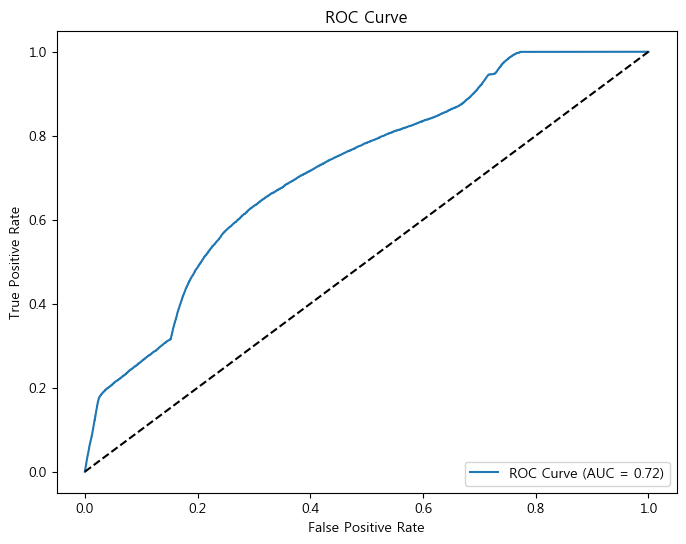

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc = roc_auc_score(y, pred_prob)
print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y, pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()